# Fase 3a: Arquitetura de Stacking Multi-Target

**Dataset:** `generated_dataset.csv` - 195.950 voos BTS domésticos EUA 2023 (Jan–Ago)

## Estrutura completa

| Secção | Conteúdo |
|---|---|
| 1–4 | Carregamento, features, pré-processamento |
| 5 | Seleção de features: Pearson + LASSO + RF importance (≥2 votos) |
| 6 | Walk-forward 5 folds temporais |
| 7 | Nível 0 - modelos base (3 por target) |
| 8 | Nível 1 - meta-modelos Ridge com cross-target |
| 9–10 | Resultados + visualizações |
| 11 | Interpretabilidade - SHAP |
| 12 | Camada de cenários (Otimista / Balanceado / Pessimista) |
| 13 | Perfis de decisão (Económico / Rápido / Sustentável / Equilibrado) |

## Arquitetura Nível 0 - Walk-Forward 5 Folds

| Target | Modelo 1 | Modelo 2 | Modelo 3 |
|---|---|---|---|
| Custo | Regressão Linear | Random Forest | XGBoost |
| Duração | Random Forest | LinearSVR | XGBoost |
| CO₂ | Modelo físico ICAO | Random Forest | XGBoost |

## Folds Walk-Forward

| Fold | Treino | Teste |
|---|---|---|
| 1 | Jan | Fev |
| 2 | Jan–Fev | Mar |
| 3 | Jan–Mar | Abr–Mai |
| 4 | Jan–Mai | Jun–Jul |
| 5 | Jan–Jul | Ago |

## 1. Setup e Imports

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)

## 2. Carregamento e Ordenação Temporal

In [58]:
PATH = 'generated_dataset.csv'

df = pd.read_csv(PATH, low_memory=False)
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
df = df.sort_values('FL_DATE').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["FL_DATE"].min().date()} → {df["FL_DATE"].max().date()}')
print()
print('Voos por mês:')
print(df.groupby('Month').size().to_string())

Shape: (195950, 29)
Período: 2023-01-01 → 2023-08-31

Voos por mês:
Month
1    23544
2    21919
3    25480
4    24383
5    25465
6    24501
7    25093
8    25565


## 3. Definição de Features e Targets

In [59]:
# Targets
TARGET_COST     = 'COST_PRED_USD'
TARGET_DURATION = 'DURATION_REAL_MIN'
TARGET_CO2      = 'CO2_kg'
TARGETS = [TARGET_COST, TARGET_DURATION, TARGET_CO2]

# Candidatas a features - sem targets, sem flags, sem datas
FEATURES_CAT = ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'Season']
FEATURES_NUM = [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'DayofMonth', 'Quarter',
    'IsWeekend', 'IsNightFlight',
    'CRS_ELAPSED_TIME', 'DEP_HOUR',
    'Rolling_DEP_DELAY',
    'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
]
ALL_CANDIDATES = FEATURES_CAT + FEATURES_NUM

available = [f for f in ALL_CANDIDATES if f in df.columns]
print(f'Features candidatas disponíveis: {len(available)}/{len(ALL_CANDIDATES)}')
for t in TARGETS:
    assert t not in available, f'LEAKAGE: {t} está nas features.'
print('Verificação de leakage: OK')

Features candidatas disponíveis: 19/19
Verificação de leakage: OK


## 4. Pré-processamento

In [60]:
df_model = df[available + TARGETS].copy()

# Label encoding para categóricas
le_dict = {}
for col in FEATURES_CAT:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

# Preencher nulls
for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

# Garantir Month disponível para folds
df_model['Month'] = df['Month'].values

print(f'Dataset de modelação: {df_model.shape}')
print(f'Nulls: {df_model.isnull().sum().sum()}')
print()
print('Targets - estatísticas:')
for t in TARGETS:
    s = df_model[t]
    print(f'  {t:<25}  mean={s.mean():.1f} | std={s.std():.1f} | min={s.min():.0f} | max={s.max():.0f}')

Dataset de modelação: (195950, 22)
Nulls: 0

Targets - estatísticas:
  COST_PRED_USD              mean=187.9 | std=70.2 | min=50 | max=539
  DURATION_REAL_MIN          mean=147.1 | std=73.0 | min=32 | max=727
  CO2_kg                     mean=21519.6 | std=13524.4 | min=3209 | max=115205


## 5. Seleção de Features

Três métodos complementares aplicados a cada target. Uma feature é mantida se selecionada por **≥ 2 dos 3 métodos**.

- **Pearson** - correlação linear com o target (|r| ≥ 0.05)
- **LASSO** - penalização L1, coeficientes nulos eliminados
- **RF importance** - top N features por importância nas árvores

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor

def select_features(df_m, feature_cols, target_col,
                    pearson_thr=0.03, top_n_rf=12):
    """
    Seleção de features por 3 métodos: Pearson + LASSO + RF importance.
    Seleciona features com ≥2 votos.
    """
    X = df_m[feature_cols]
    y = df_m[target_col]

    # 1. Pearson
    pearson = X.corrwith(y).abs()
    pearson_sel = set(pearson[pearson >= pearson_thr].index)

    # 2. LASSO (features normalizadas)
    sc = StandardScaler()
    X_sc = sc.fit_transform(X)
    lasso = LassoCV(cv=5, max_iter=5000, random_state=SEED, n_jobs=-1)
    lasso.fit(X_sc, y)
    coef = pd.Series(np.abs(lasso.coef_), index=feature_cols)
    lasso_sel = set(coef[coef > 0].index)

    # 3. RF importance (RF rápido, só para seleção)
    rf_s = RandomForestRegressor(n_estimators=100, max_depth=8,
                                  random_state=SEED, n_jobs=-1)
    rf_s.fit(X, y)
    imp = pd.Series(rf_s.feature_importances_, index=feature_cols)
    rf_sel = set(imp.nlargest(top_n_rf).index)

    # Decisão ≥2 votos
    summary = pd.DataFrame({
        'feature': feature_cols,
        'pearson': [f in pearson_sel for f in feature_cols],
        'lasso':   [f in lasso_sel   for f in feature_cols],
        'rf':      [f in rf_sel      for f in feature_cols],
    })
    summary['votes']    = summary[['pearson','lasso','rf']].sum(axis=1)
    summary['selected'] = summary['votes'] >= 2
    selected = summary[summary['selected']]['feature'].tolist()

    return summary, selected, pearson

print('Função de seleção de features pronta.')

Função de seleção de features pronta.


In [62]:
print('A executar seleção de features para os 3 targets...')

feature_sets   = {}
summaries      = {}
pearson_scores = {}

for target, label in [
    (TARGET_COST,     'Custo'),
    (TARGET_DURATION, 'Duração'),
    (TARGET_CO2,      'CO₂'),
]:
    print(f'--- {label} ---')
    s, selected, pearson = select_features(df_model, available, target)
    feature_sets[target]   = selected
    summaries[target]      = s
    pearson_scores[target] = pearson
    print(f'  Features selecionadas ({len(selected)}): {selected}')
    print()

A executar seleção de features para os 3 targets...
--- Custo ---
  Features selecionadas (13): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

--- Duração ---
  Features selecionadas (11): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'Rolling_DEP_DELAY', 'ORIGIN_LON', 'DEST_LON']

--- CO₂ ---
  Features selecionadas (10): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LON']



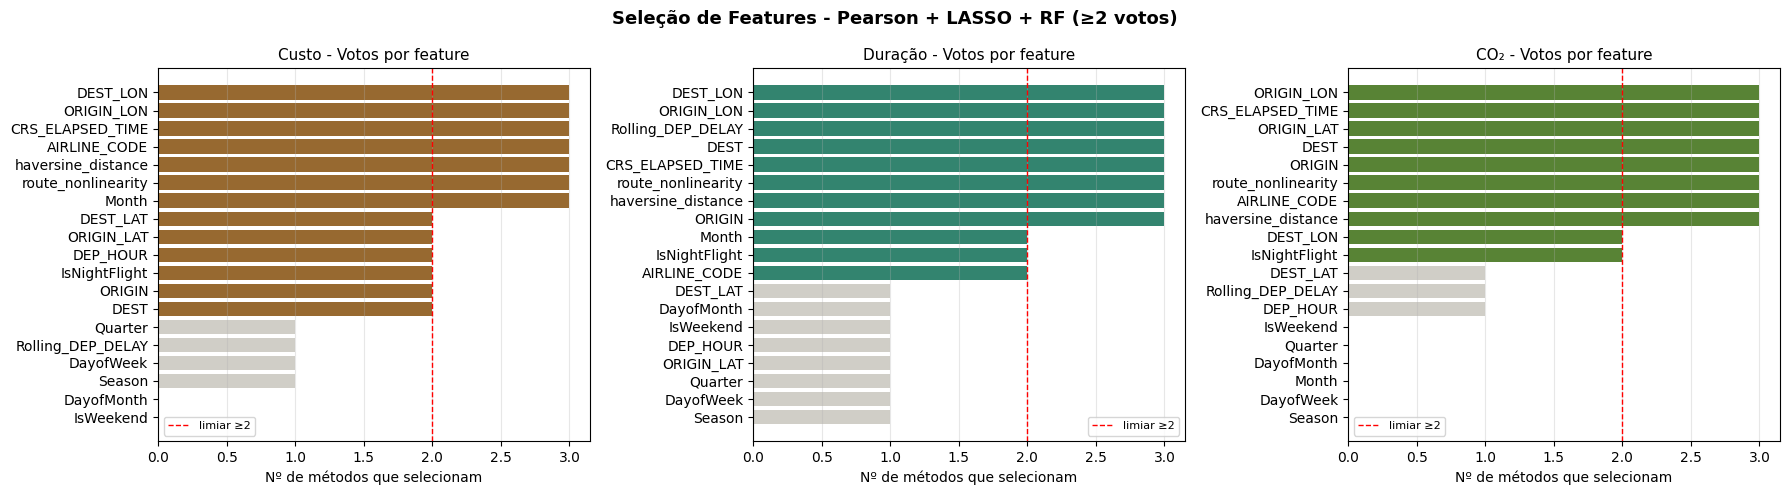

In [63]:
# Visualização: votos por target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_t = [TARGET_COST, TARGET_DURATION, TARGET_CO2]
titles_t  = ['Custo', 'Duração', 'CO₂']
colors_t  = ['#AMBER', '#TEAL', '#GREEN']
hex_t     = ['#854F0B', '#0F6E56', '#3B6D11']

for ax, target, title, color in zip(axes, labels_t, titles_t, hex_t):
    s = summaries[target].sort_values('votes', ascending=True)
    bar_colors = [color if v >= 2 else '#C8C6BE' for v in s['votes']]
    ax.barh(s['feature'], s['votes'], color=bar_colors, alpha=0.85)
    ax.axvline(2, color='red', linestyle='--', lw=1, label='limiar ≥2')
    ax.set_title(f'{title} - Votos por feature', fontsize=11)
    ax.set_xlabel('Nº de métodos que selecionam')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Seleção de Features - Pearson + LASSO + RF (≥2 votos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Walk-Forward 5 Folds e Funções Auxiliares

In [64]:
FOLDS = [
    {'train_months': [1],                   'test_months': [2]},
    {'train_months': [1,2],                 'test_months': [3]},
    {'train_months': [1,2,3],               'test_months': [4,5]},
    {'train_months': [1,2,3,4,5],           'test_months': [6,7]},
    {'train_months': [1,2,3,4,5,6,7],       'test_months': [8]},
]

print('Walk-forward 5 folds:')
for i, fold in enumerate(FOLDS):
    tr = df_model['Month'].isin(fold['train_months']).sum()
    te = df_model['Month'].isin(fold['test_months']).sum()
    print(f'  Fold {i+1}: treino meses {fold["train_months"]:} ({tr:,}) '
          f'→ teste meses {fold["test_months"]:} ({te:,})')

Walk-forward 5 folds:
  Fold 1: treino meses [1] (23,544) → teste meses [2] (21,919)
  Fold 2: treino meses [1, 2] (45,463) → teste meses [3] (25,480)
  Fold 3: treino meses [1, 2, 3] (70,943) → teste meses [4, 5] (49,848)
  Fold 4: treino meses [1, 2, 3, 4, 5] (120,791) → teste meses [6, 7] (49,594)
  Fold 5: treino meses [1, 2, 3, 4, 5, 6, 7] (170,385) → teste meses [8] (25,565)


In [65]:
def evaluate(name, y_true, y_pred):
    return {
        'model': name,
        'rmse':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae':   mean_absolute_error(y_true, y_pred),
        'r2':    r2_score(y_true, y_pred) * 100,
    }

def fmt(d):
    return f"RMSE={d['rmse']:.3f} | MAE={d['mae']:.3f} | R²={d['r2']:.3f}%"

def walk_forward_oof(models_dict, df_m, y_series, feature_cols, folds, scale=False):
    """
    Walk-forward OOF predictions.
    Retorna (oof_matrix [n x n_models], oof_mask, trained_models_last_fold)
    """
    n = len(df_m)
    n_models = len(models_dict)
    oof_matrix = np.zeros((n, n_models))
    oof_mask   = np.zeros(n, dtype=bool)
    trained    = {name: None for name in models_dict}

    for fold_i, fold in enumerate(folds):
        tr_mask = df_m['Month'].isin(fold['train_months']).values
        te_mask = df_m['Month'].isin(fold['test_months']).values

        X_tr_raw = df_m.loc[tr_mask, feature_cols].values
        X_te_raw = df_m.loc[te_mask, feature_cols].values
        y_tr     = y_series.values[tr_mask]

        if scale:
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr_raw)
            X_te = sc.transform(X_te_raw)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        for j, (name, model) in enumerate(models_dict.items()):
            model.fit(X_tr, y_tr)
            te_idx = np.where(te_mask)[0]
            oof_matrix[te_idx, j] = model.predict(X_te)
            if fold_i == len(folds) - 1:
                trained[name] = model

        oof_mask[te_mask] = True

    return oof_matrix, oof_mask, trained

print('Funções auxiliares prontas.')

Funções auxiliares prontas.


## 7. Nível 0 - Modelos Base

### 7.1 Pipeline - Custo (LR + RF + XGBoost)

In [66]:
import time

y_cost = df_model[TARGET_COST]
feats_cost = feature_sets[TARGET_COST]

models_cost = {
    'LR_cost':  LinearRegression(),
    'RF_cost':  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGB_cost': xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features custo ({len(feats_cost)}): {feats_cost}')
t0 = time.time()
oof_cost, mask_cost, trained_cost = walk_forward_oof(
    models_cost, df_model, y_cost, feats_cost, FOLDS, scale=True
)
print(f'Tempo: {time.time()-t0:.1f}s')
print()

results_cost_l0 = []
y_true_cost = y_cost.values[mask_cost]
for j, name in enumerate(models_cost):
    r = evaluate(name, y_true_cost, oof_cost[mask_cost, j])
    results_cost_l0.append(r)
    print(f'{name:<12} {fmt(r)}')

Features custo (13): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']
Tempo: 118.9s

LR_cost      RMSE=50.465 | MAE=39.283 | R²=48.272%
RF_cost      RMSE=39.477 | MAE=31.478 | R²=68.345%
XGB_cost     RMSE=36.544 | MAE=29.188 | R²=72.874%


### 7.2 Pipeline - Duração (RF + LinearSVR + XGBoost)

In [67]:
y_dur = df_model[TARGET_DURATION]
feats_dur = feature_sets[TARGET_DURATION]

models_dur = {
    'RF_dur':      RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'LinSVR_dur':  LinearSVR(C=1.0, max_iter=3000, random_state=SEED),
    'XGB_dur':     xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features duração ({len(feats_dur)}): {feats_dur}')
t0 = time.time()
oof_dur, mask_dur, trained_dur = walk_forward_oof(
    models_dur, df_model, y_dur, feats_dur, FOLDS, scale=True
)
print(f'Tempo: {time.time()-t0:.1f}s')
print()

results_dur_l0 = []
y_true_dur = y_dur.values[mask_dur]
for j, name in enumerate(models_dur):
    r = evaluate(name, y_true_dur, oof_dur[mask_dur, j])
    results_dur_l0.append(r)
    print(f'{name:<14} {fmt(r)}')

Features duração (11): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'Rolling_DEP_DELAY', 'ORIGIN_LON', 'DEST_LON']
Tempo: 136.7s

RF_dur         RMSE=15.296 | MAE=10.636 | R²=95.604%
LinSVR_dur     RMSE=14.495 | MAE=9.657 | R²=96.052%
XGB_dur        RMSE=14.751 | MAE=10.080 | R²=95.911%


### 7.3 Pipeline - CO₂ (Modelo Físico ICAO + RF + XGBoost)

In [68]:
y_co2 = df_model[TARGET_CO2]
feats_co2 = feature_sets[TARGET_CO2]

# Modelo físico ICAO - determinístico, sem treino
ICAO_CORR    = 95.0
FUEL_KG_KM   = 4.5
CO2_PER_FUEL = 3.16
icao_pred_all = (
    (df['haversine_distance'] + ICAO_CORR) * FUEL_KG_KM * CO2_PER_FUEL
).values

# Modelos ML para CO2 (aprendem desvios face ao modelo físico)
models_co2_ml = {
    'RF_co2':  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGB_co2': xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features CO2 ({len(feats_co2)}): {feats_co2}')
t0 = time.time()
oof_co2_ml, mask_co2, trained_co2 = walk_forward_oof(
    models_co2_ml, df_model, y_co2, feats_co2, FOLDS, scale=True
)
print(f'Tempo: {time.time()-t0:.1f}s')
print()

# Construir matriz OOF CO2: [ICAO_physical | RF | XGB]
oof_co2 = np.column_stack([icao_pred_all, oof_co2_ml])

results_co2_l0 = []
y_true_co2 = y_co2.values[mask_co2]
for j, name in enumerate(['ICAO_physical','RF_co2','XGB_co2']):
    r = evaluate(name, y_true_co2, oof_co2[mask_co2, j])
    results_co2_l0.append(r)
    print(f'{name:<16} {fmt(r)}')

Features CO2 (10): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LON']
Tempo: 75.7s

ICAO_physical    RMSE=1016.096 | MAE=700.689 | R²=99.436%
RF_co2           RMSE=110.576 | MAE=10.820 | R²=99.993%
XGB_co2          RMSE=136.787 | MAE=50.123 | R²=99.990%


## 8. Nível 1 - Meta-modelos Ridge com Cross-Target

Cada Ridge recebe:
- Previsões OOF dos 3 modelos base do próprio target
- Features originais selecionadas
- Previsão média dos outros dois targets (cross-target)

O Ridge aprende a combinar estas fontes sem overfitting, dado que usa as previsões *out-of-fold* (o modelo base nunca viu os dados de teste durante o treino).

In [69]:
# Máscara OOF válida (igual para todos - todos os folds têm o mesmo mask)
oof_idx = np.where(mask_cost)[0]

# Features para o nível 1 (seleção comum: numéricas, sem categóricas redundantes)
FEATS_L1 = [f for f in [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'Quarter', 'IsWeekend',
    'CRS_ELAPSED_TIME', 'DEP_HOUR',
    'DEP_DELAY', 'Rolling_DEP_DELAY',
] if f in df_model.columns]

X_l1 = df_model.iloc[oof_idx][FEATS_L1].values
sc_l1 = StandardScaler()
X_l1_sc = sc_l1.fit_transform(X_l1)

# OOF matrices para os índices com previsões válidas
oof_c = oof_cost[oof_idx]     # n × 3
oof_d = oof_dur[oof_idx]      # n × 3
oof_e = oof_co2[oof_idx]      # n × 3

# Média cross-target (previsão dos outros targets)
mean_dur  = oof_d.mean(axis=1, keepdims=True)
mean_co2  = oof_e.mean(axis=1, keepdims=True)
mean_cost = oof_c.mean(axis=1, keepdims=True)

print(f'OOF índices: {len(oof_idx):,}')
print(f'Features L1: {FEATS_L1}')

OOF índices: 172,406
Features L1: ['haversine_distance', 'route_nonlinearity', 'Month', 'DayofWeek', 'Quarter', 'IsWeekend', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY']


In [70]:
y_c = y_cost.values[oof_idx]
y_d = y_dur.values[oof_idx]
y_e = y_co2.values[oof_idx]

# Ridge Custo
X_meta_cost = np.hstack([oof_c, X_l1_sc, mean_dur, mean_co2])
ridge_cost = Ridge(alpha=1.0)
ridge_cost.fit(X_meta_cost, y_c)
pred_cost_final = ridge_cost.predict(X_meta_cost)
r_cost = evaluate('Ridge_cost', y_c, pred_cost_final)
print(f'Ridge CUSTO:    {fmt(r_cost)}')

# Ridge Duração
X_meta_dur = np.hstack([oof_d, X_l1_sc, mean_cost, mean_co2])
ridge_dur = Ridge(alpha=1.0)
ridge_dur.fit(X_meta_dur, y_d)
pred_dur_final = ridge_dur.predict(X_meta_dur)
r_dur = evaluate('Ridge_dur', y_d, pred_dur_final)
print(f'Ridge DURAÇÃO:  {fmt(r_dur)}')

# Ridge CO₂
X_meta_co2 = np.hstack([oof_e, X_l1_sc, mean_cost, mean_dur])
ridge_co2 = Ridge(alpha=1.0)
ridge_co2.fit(X_meta_co2, y_e)
pred_co2_final = ridge_co2.predict(X_meta_co2)
r_co2 = evaluate('Ridge_co2', y_e, pred_co2_final)
print(f'Ridge CO₂:      {fmt(r_co2)}')

Ridge CUSTO:    RMSE=36.324 | MAE=29.036 | R²=73.201%
Ridge DURAÇÃO:  RMSE=14.178 | MAE=9.665 | R²=96.223%
Ridge CO₂:      RMSE=96.400 | MAE=24.116 | R²=99.995%


## 9. Tabela Comparativa Final

In [71]:
print('Resultados - Fase 3a (sem features externas):')

sections = [
    ('CUSTO (USD)',   results_cost_l0 + [r_cost]),
    ('DURAÇÃO (min)', results_dur_l0  + [r_dur]),
    ('CO₂ (kg)',      results_co2_l0  + [r_co2]),
]

# Calcular erro relativo
means = {
    TARGET_COST:     y_c.mean(),
    TARGET_DURATION: y_d.mean(),
    TARGET_CO2:      y_e.mean(),
}

for title, results in sections:
    print(f'\n{title}')
    print(f'  {"Modelo":<16} {"RMSE":>10} {"MAE":>10} {"R²%":>10} {"RMSE_rel%":>12}')
    print('  ' + '-'*58)
    mean_t = list(means.values())[['CUSTO','DURAÇÃO','CO₂'].index(title.split(' ')[0])]
    for r in results:
        marker = ' Nível 1' if 'Ridge' in r['model'] else ''
        rmse_rel = r['rmse'] / mean_t * 100
        print(f'  {r["model"]:<16} {r["rmse"]:>10.3f} {r["mae"]:>10.3f} '
              f'{r["r2"]:>10.3f}% {rmse_rel:>11.1f}%{marker}')
print('='*75)

Resultados - Fase 3a (sem features externas):

CUSTO (USD)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  ----------------------------------------------------------
  LR_cost              50.465     39.283     48.272%        26.8%
  RF_cost              39.477     31.478     68.345%        21.0%
  XGB_cost             36.544     29.188     72.874%        19.4%
  Ridge_cost           36.324     29.036     73.201%        19.3% Nível 1

DURAÇÃO (min)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  ----------------------------------------------------------
  RF_dur               15.296     10.636     95.604%        10.4%
  LinSVR_dur           14.495      9.657     96.052%         9.9%
  XGB_dur              14.751     10.080     95.911%        10.0%
  Ridge_dur            14.178      9.665     96.223%         9.7% Nível 1

CO₂ (kg)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  -----------------------------------------------------

## 10. Visualizações

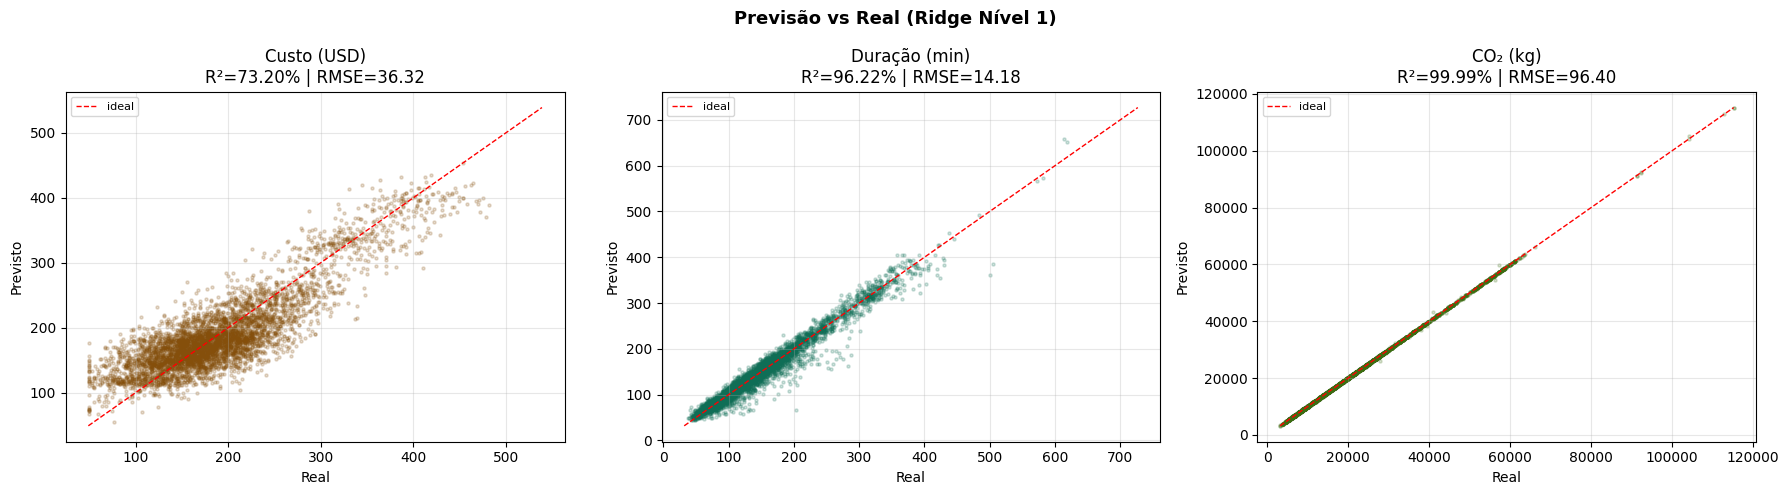

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    ('Custo (USD)',   y_c, pred_cost_final, '#854F0B'),
    ('Duração (min)', y_d, pred_dur_final,  '#0F6E56'),
    ('CO₂ (kg)',      y_e, pred_co2_final,  '#3B6D11'),
]

for ax, (title, y_true, y_pred, color) in zip(axes, plot_data):
    sample = np.random.choice(len(y_true), min(5000, len(y_true)), replace=False)
    ax.scatter(y_true[sample], y_pred[sample], alpha=0.2, s=5, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='ideal')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel(f'Real')
    ax.set_ylabel('Previsto')
    ax.set_title(f'{title}\nR²={r2*100:.2f}% | RMSE={rmse:.2f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Previsão vs Real (Ridge Nível 1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3a_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

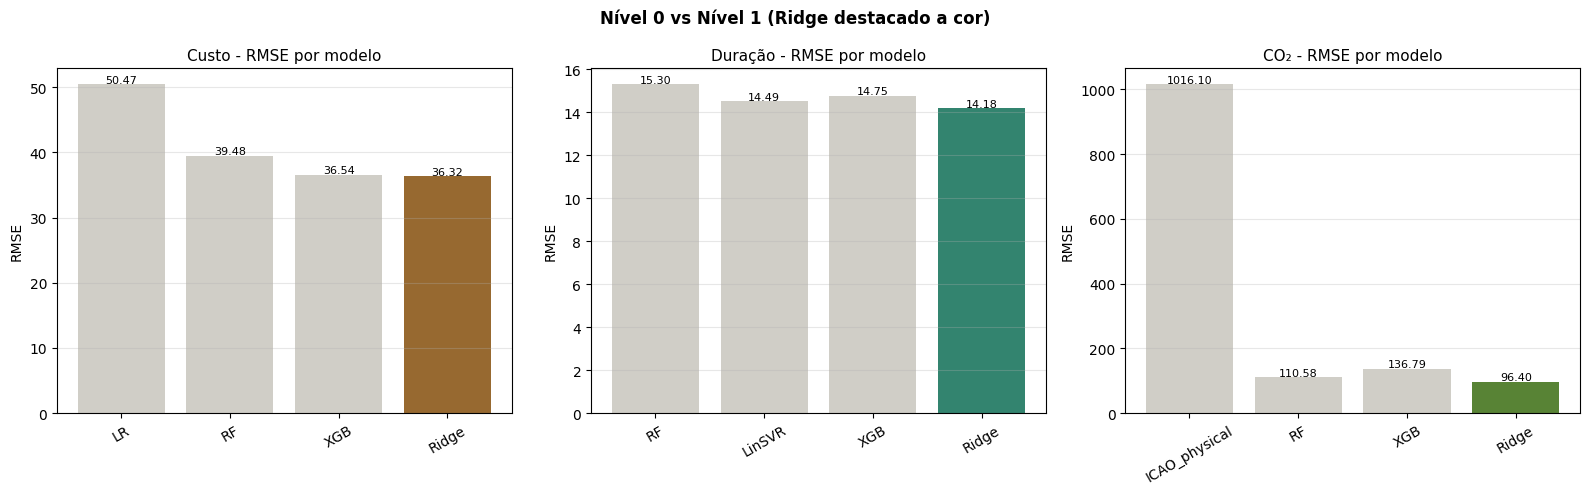

In [73]:
# RMSE por modelo - comparação nível 0 vs nível 1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, results, color) in zip(axes, [
    ('Custo',   results_cost_l0 + [r_cost],  '#854F0B'),
    ('Duração', results_dur_l0  + [r_dur],   '#0F6E56'),
    ('CO₂',     results_co2_l0  + [r_co2],   '#3B6D11'),
]):
    names = [r['model'].replace('_cost','').replace('_dur','').replace('_co2','') for r in results]
    rmses = [r['rmse'] for r in results]
    cols  = [color if 'Ridge' in r['model'] else '#C8C6BE' for r in results]
    bars  = ax.bar(names, rmses, color=cols, alpha=0.85)
    for bar, v in zip(bars, rmses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max(rmses),
                f'{v:.2f}', ha='center', fontsize=8)
    ax.set_title(f'{title} - RMSE por modelo', fontsize=11)
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Nível 0 vs Nível 1 (Ridge destacado a cor)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3a_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Interpretabilidade - SHAP

- SHAP (SHapley Additive exPlanations) aplicado ao meta-modelo Ridge do Nível 1.
- Mostra a contribuição de cada feature para cada previsão individual.
- As 3 primeiras colunas são as previsões dos modelos base - é esperado que dominem.

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para Custo...


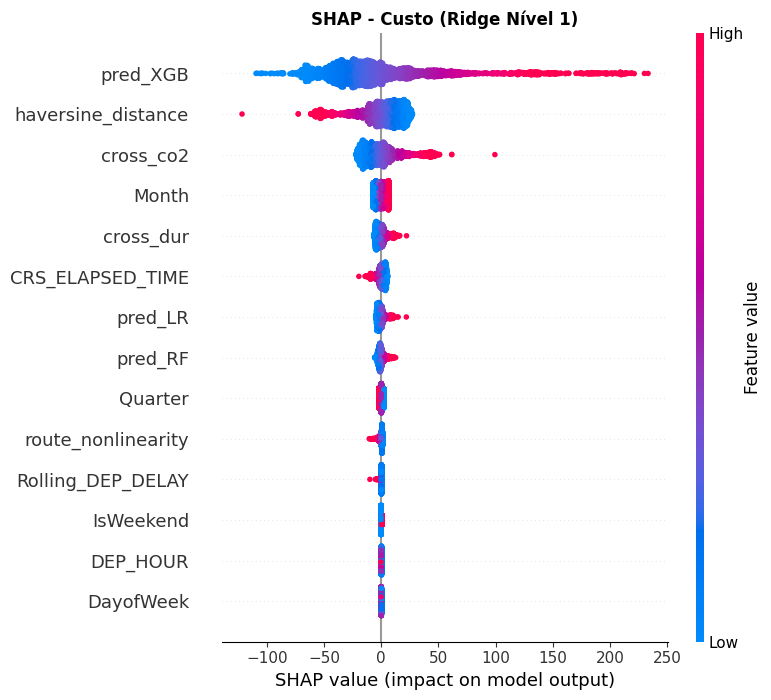

In [74]:
# Nomes das colunas do meta-modelo
meta_cols = {
    'cost':     ['pred_LR', 'pred_RF', 'pred_XGB'] + FEATS_L1 + ['cross_dur', 'cross_co2'],
    'duration': ['pred_RF', 'pred_LinSVR', 'pred_XGB'] + FEATS_L1 + ['cross_cost', 'cross_co2'],
    'co2':      ['pred_ICAO', 'pred_RF', 'pred_XGB'] + FEATS_L1 + ['cross_cost', 'cross_dur'],
}

# SHAP - Custo
print('A calcular SHAP para Custo...')
sample_idx = np.random.choice(len(X_meta_cost), min(3000, len(X_meta_cost)), replace=False)
explainer_cost = shap.LinearExplainer(ridge_cost, X_meta_cost)
shap_cost = explainer_cost.shap_values(X_meta_cost[sample_idx])

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_cost, X_meta_cost[sample_idx],
                  feature_names=meta_cols['cost'],
                  plot_type='dot', show=False)
plt.title('SHAP - Custo (Ridge Nível 1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_cost.png', dpi=150, bbox_inches='tight')
plt.show()

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para Duração...


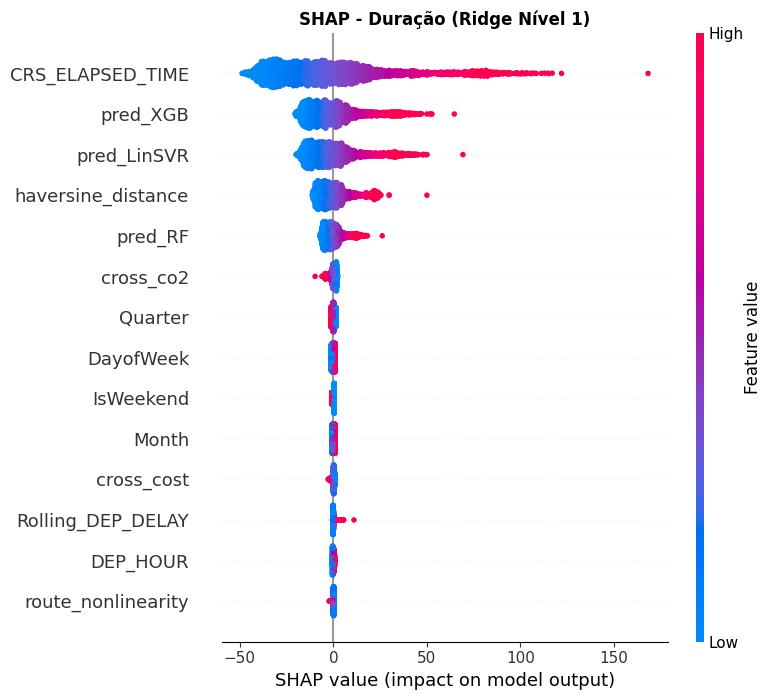

In [75]:
# SHAP - Duração
print('A calcular SHAP para Duração...')
explainer_dur = shap.LinearExplainer(ridge_dur, X_meta_dur)
shap_dur = explainer_dur.shap_values(X_meta_dur[sample_idx])

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_dur, X_meta_dur[sample_idx],
                  feature_names=meta_cols['duration'],
                  plot_type='dot', show=False)
plt.title('SHAP - Duração (Ridge Nível 1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_duration.png', dpi=150, bbox_inches='tight')
plt.show()

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para CO₂...


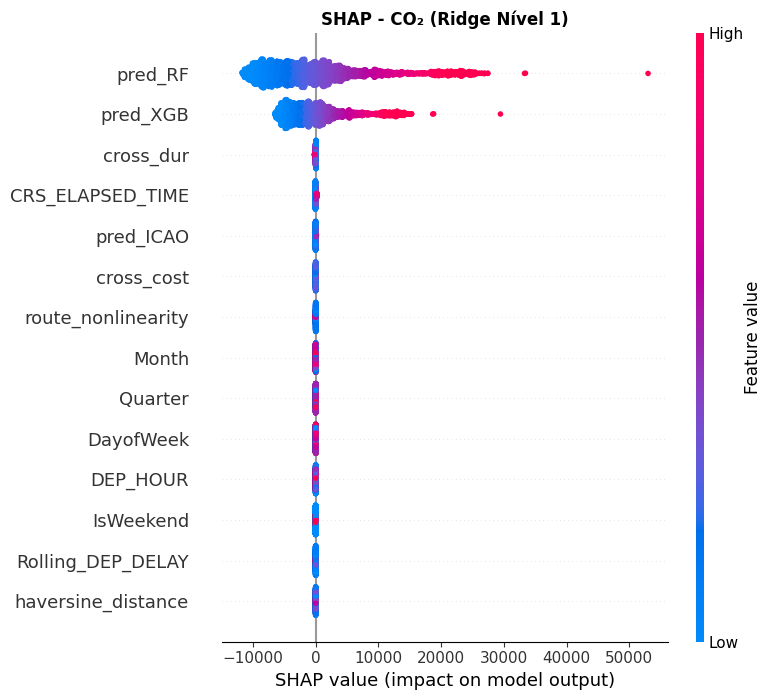

In [76]:
# SHAP - CO2
print('A calcular SHAP para CO₂...')
explainer_co2 = shap.LinearExplainer(ridge_co2, X_meta_co2)
shap_co2 = explainer_co2.shap_values(X_meta_co2[sample_idx])

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_co2, X_meta_co2[sample_idx],
                  feature_names=meta_cols['co2'],
                  plot_type='dot', show=False)
plt.title('SHAP - CO₂ (Ridge Nível 1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_co2.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Camada de Cenários

O modelo **não é retreinado** - apenas as features contextuais de entrada mudam.

Em Fase 3a, sem features externas (combustível, conflito, clima), os cenários variam as features operacionais disponíveis no dataset:
- **DEP_DELAY** - atraso operacional à partida
- **Rolling_DEP_DELAY** - contexto histórico de atrasos na rota

Na Fase 3b, os cenários incluirão preço de combustível, conflito ativo, clima e câmbio - com impacto muito mais diferenciado entre cenários.

In [ ]:
# Cenários baseados em Rolling_DEP_DELAY (média histórica - disponível pré-voo)
p10_roll   = df_model['Rolling_DEP_DELAY'].quantile(0.10)
mean_roll  = df_model['Rolling_DEP_DELAY'].mean()
p90_roll   = df_model['Rolling_DEP_DELAY'].quantile(0.90)

SCENARIOS = {
    'Otimista':  {'Rolling_DEP_DELAY': p10_roll},
    'Balanceado': {'Rolling_DEP_DELAY': mean_roll},
    'Pessimista': {'Rolling_DEP_DELAY': p90_roll},
}

print('Cenários definidos (Fase 3a — Rolling_DEP_DELAY):')
for nome, vals in SCENARIOS.items():
    print(f'  {nome:<12}: Rolling_DEP_DELAY={vals["Rolling_DEP_DELAY"]:+.1f}')
print()
print('Rolling_DEP_DELAY (média histórica, disponível pré-voo)')

Cenários definidos (Fase 3a — Rolling_DEP_DELAY):
  Optimista   : Rolling_DEP_DELAY=-4.0
  Balanceado  : Rolling_DEP_DELAY=+15.3
  Pessimista  : Rolling_DEP_DELAY=+42.2

Rolling_DEP_DELAY (média histórica, disponível pré-voo)


In [78]:
# Aplicar cenários - só as features contextuais mudam no X_l1
# Os OOF de nível 0 mantêm-se (o modelo não é retreinado)
results_scenarios = {}

for nome, vals in SCENARIOS.items():
    X_l1_sc_cen = X_l1_sc.copy()

    # Modificar DEP_DELAY e Rolling_DEP_DELAY no X_l1
    for feat, val in vals.items():
        if feat in FEATS_L1:
            idx_feat = FEATS_L1.index(feat)
            # desescalar, substituir, reescalar
            col_mean = sc_l1.mean_[idx_feat]
            col_std  = sc_l1.scale_[idx_feat]
            X_l1_sc_cen[:, idx_feat] = (val - col_mean) / col_std

    # Reconstruir X_meta com features modificadas
    X_meta_cost_cen = np.hstack([oof_c, X_l1_sc_cen, mean_dur, mean_co2])
    X_meta_dur_cen  = np.hstack([oof_d, X_l1_sc_cen, mean_cost, mean_co2])
    X_meta_co2_cen  = np.hstack([oof_e, X_l1_sc_cen, mean_cost, mean_dur])

    pred_cost_cen = ridge_cost.predict(X_meta_cost_cen)
    pred_dur_cen  = ridge_dur.predict(X_meta_dur_cen)
    pred_co2_cen  = ridge_co2.predict(X_meta_co2_cen)

    results_scenarios[nome] = {
        'cost': pred_cost_cen,
        'dur':  pred_dur_cen,
        'co2':  pred_co2_cen,
    }
    print(f'{nome:<12}: custo={pred_cost_cen.mean():.1f} USD | '
          f'dur={pred_dur_cen.mean():.1f} min | '
          f'CO2={pred_co2_cen.mean():.0f} kg')

Optimista   : custo=188.5 USD | dur=146.6 min | CO2=21514 kg
Balanceado  : custo=188.2 USD | dur=146.9 min | CO2=21514 kg
Pessimista  : custo=187.8 USD | dur=147.4 min | CO2=21514 kg


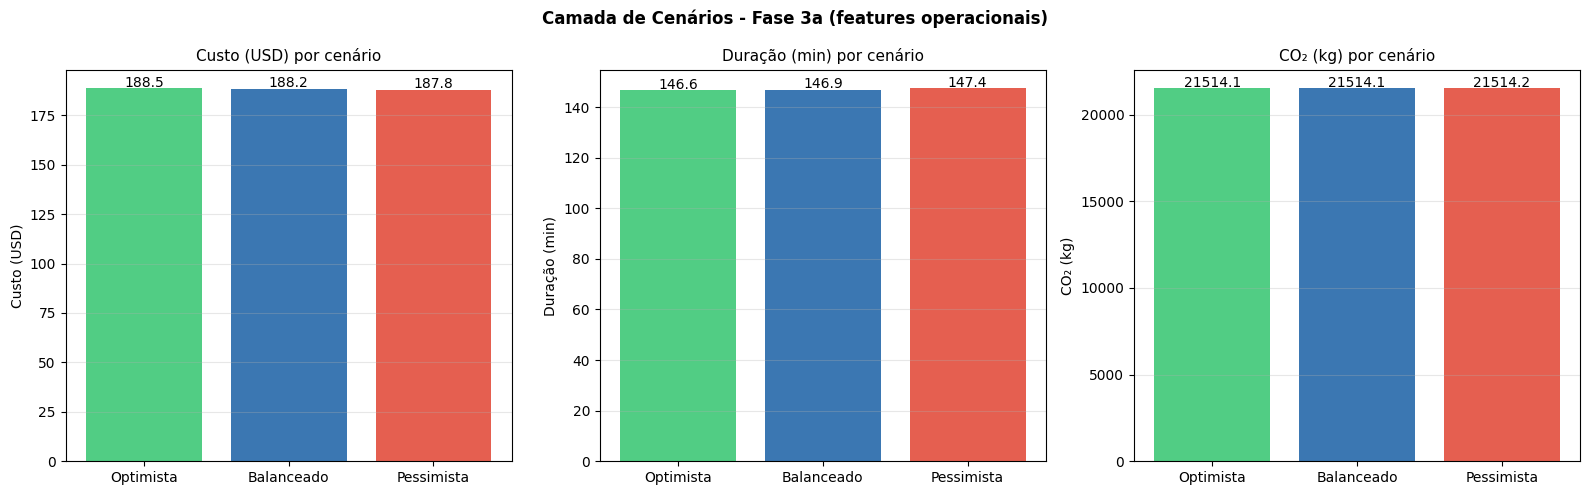

In [ ]:
# Visualização cenários
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cen_names  = list(SCENARIOS.keys())
cen_colors = {'Otimista': '#32c56f', 'Balanceado': '#185FA5', 'Pessimista': '#e14331'}

metrics = [('cost', 'Custo (USD)'), ('dur', 'Duração (min)'), ('co2', 'CO₂ (kg)')]
for ax, (key, label) in zip(axes, metrics):
    vals   = [results_scenarios[c][key].mean() for c in cen_names]
    colors = [cen_colors[c] for c in cen_names]
    bars   = ax.bar(cen_names, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max(vals),
                f'{v:.1f}', ha='center', fontsize=10)
    ax.set_title(f'{label} por cenário', fontsize=11)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Camada de Cenários - Fase 3a (features operacionais)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Perfis de Decisão - Score Multiobjetivo

$$score = (w_c \times custo_{norm}) + (w_t \times dur_{norm}) + (w_e \times CO_2{norm})$$

Os valores são normalizados para [0,1] antes de aplicar os pesos.
**Score mais baixo = opção mais favorável** para o perfil.

| Perfil | w_custo | w_tempo | w_CO₂ |
|---|---|---|---|
| Económico | 0.70 | 0.20 | 0.10 |
| Rápido | 0.10 | 0.80 | 0.10 |
| Sustentável | 0.10 | 0.10 | 0.80 |
| Equilibrado | 0.33 | 0.34 | 0.33 |

In [80]:
PROFILES = {
    'Económico':   {'w_cost': 0.70, 'w_time': 0.20, 'w_co2': 0.10},
    'Rápido':      {'w_cost': 0.10, 'w_time': 0.80, 'w_co2': 0.10},
    'Sustentável': {'w_cost': 0.10, 'w_time': 0.10, 'w_co2': 0.80},
    'Equilibrado': {'w_cost': 0.33, 'w_time': 0.34, 'w_co2': 0.33},
}

def normalise(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

# Calcular scores por cenário e perfil
score_rows = []
for cen, preds in results_scenarios.items():
    c_n = normalise(preds['cost'])
    d_n = normalise(preds['dur'])
    e_n = normalise(preds['co2'])
    for profile, w in PROFILES.items():
        score = w['w_cost']*c_n + w['w_time']*d_n + w['w_co2']*e_n
        score_rows.append({
            'cenario':       cen,
            'perfil':        profile,
            'score_medio':   score.mean(),
            'custo_medio':   preds['cost'].mean(),
            'dur_media':     preds['dur'].mean(),
            'co2_medio':     preds['co2'].mean(),
        })

df_scores = pd.DataFrame(score_rows)
print('Scores médios por perfil e cenário:')
print(df_scores.pivot(index='perfil', columns='cenario', values='score_medio').round(4).to_string())

Scores médios por perfil e cenário:
cenario      Balanceado  Optimista  Pessimista
perfil                                        
Económico        0.2827     0.2827      0.2827
Equilibrado      0.2208     0.2208      0.2208
Rápido           0.1840     0.1840      0.1840
Sustentável      0.1810     0.1810      0.1810


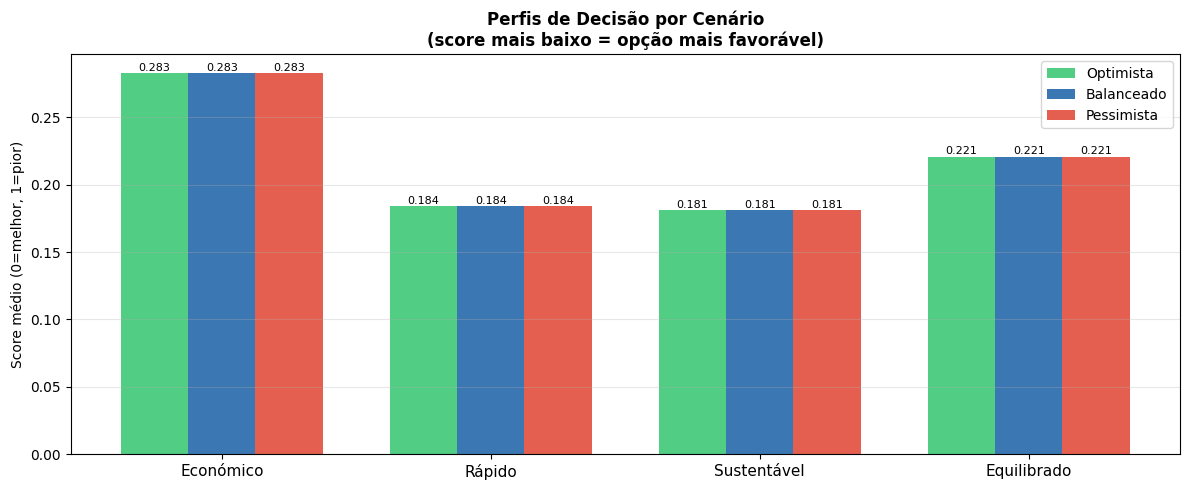

In [81]:
# Visualização dos scores
fig, ax = plt.subplots(figsize=(12, 5))
profile_names = list(PROFILES.keys())
x = np.arange(len(profile_names))
width = 0.25

for i, (cen, color) in enumerate(cen_colors.items()):
    scores = [df_scores[(df_scores['cenario']==cen) &
                        (df_scores['perfil']==p)]['score_medio'].values[0]
              for p in profile_names]
    bars = ax.bar(x + i*width, scores, width, label=cen, color=color, alpha=0.85)
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(profile_names, fontsize=11)
ax.set_ylabel('Score médio (0=melhor, 1=pior)')
ax.set_title('Perfis de Decisão por Cenário\n(score mais baixo = opção mais favorável)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_decision_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Resumo

In [82]:
print('RESUMO - Notebook 05 Fase 3a:')
print(f'Dataset: {len(df_model):,} voos · 8 meses (Jan–Ago 2023)')
print(f'Validação: walk-forward 5 folds temporais')
print()

print('Seleção de features (Pearson + LASSO + RF, ≥2 votos):')
for t, label in [(TARGET_COST,'Custo'),(TARGET_DURATION,'Duração'),(TARGET_CO2,'CO₂')]:
    print(f'  {label}: {len(feature_sets[t])} features - {feature_sets[t]}')

print()
print('Resultados finais (Ridge Nível 1 com cross-target):')
for r, label in [(r_cost,'Custo (USD)  '),(r_dur,'Duração (min)'),(r_co2,'CO₂ (kg)     ')]:
    print(f'  {label}  RMSE={r["rmse"]:.3f} | MAE={r["mae"]:.3f} | R²={r["r2"]:.3f}%')

print()
print('Cenários (features operacionais variadas - Fase 3a):')
for cen, preds in results_scenarios.items():
    print(f'  {cen:<12}: ${preds["cost"].mean():.0f} USD | '
          f'{preds["dur"].mean():.0f} min | {preds["co2"].mean():.0f} kg CO₂')

print()
print('Figuras geradas:')
figs = ['fig_feature_selection', 'fig_fase3a_scatter', 'fig_fase3a_rmse',
        'fig_shap_cost', 'fig_shap_duration', 'fig_shap_co2',
        'fig_scenarios', 'fig_decision_profiles']
for f in figs:
    print(f'  {f}.png')

print()
print('Próximo passo - Fase 3b:')
print('  Adicionar features externas (jet fuel · câmbio · carbono · clima)')
print('  Repetir arquitetura e comparar resultados com Fase 3a')

RESUMO - Notebook 05 Fase 3a:
Dataset: 195,950 voos · 8 meses (Jan–Ago 2023)
Validação: walk-forward 5 folds temporais

Seleção de features (Pearson + LASSO + RF, ≥2 votos):
  Custo: 13 features - ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']
  Duração: 11 features - ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'Month', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'Rolling_DEP_DELAY', 'ORIGIN_LON', 'DEST_LON']
  CO₂: 10 features - ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LON']

Resultados finais (Ridge Nível 1 com cross-target):
  Custo (USD)    RMSE=36.324 | MAE=29.036 | R²=73.201%
  Duração (min)  RMSE=14.178 | MAE=9.665 | R²=96.223%
  CO₂ (kg)       RMSE=96.400 | MAE=24.116 | R²=99.995%

Cenários (features ope